<a href="https://colab.research.google.com/github/Grt-404/Archive/blob/main/Object_detection_using_DETR_architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install -q datasets transformers accelerate timm trackio
!pip install -q -U albumentations>=1.4.5 torchmetrics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires gradio-client==1.14.0, but you have gradio-client 2.5.0 which is incompatible.


In [8]:
import torch
import numpy as np
import albumentations as A
from functools import partial
from dataclasses import dataclass
from datasets import load_dataset
from transformers.image_transforms import center_to_corners_format
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer
)


MODEL_NAME = "microsoft/conditional-detr-resnet-50"
IMAGE_SIZE = 480

def main():
    try:
        cppe5 = load_dataset("cppe-5")
    except Exception as e:
        print(f"Loading 'cppe-5' failed: {e}")
        print("Trying alternative: rishitdagli/cppe-5...")
        cppe5 = load_dataset("rishitdagli/cppe-5")

    if "validation" not in cppe5:
        if "test" in cppe5:
            cppe5["validation"] = cppe5["test"]
        else:
            split = cppe5["train"].train_test_split(0.15, seed=1337)
            cppe5["train"] = split["train"]
            cppe5["validation"] = split["test"]

    print(f"Train samples: {len(cppe5['train'])}")
    print(f"Validation samples: {len(cppe5['validation'])}")

    categories = ["Coverall", "Face_Shield", "Gloves", "Goggles", "Mask"]
    id2label = {index: x for index, x in enumerate(categories)}
    label2id = {v: k for k, v in id2label.items()}
    print(f"Categories: {categories}")

    image_processor = AutoImageProcessor.from_pretrained(
        MODEL_NAME,
        do_resize=True,
        size={"max_height": IMAGE_SIZE, "max_width": IMAGE_SIZE},
        do_pad=True,
        pad_size={"height": IMAGE_SIZE, "width": IMAGE_SIZE},
    )

    train_augment_and_transform = A.Compose(
        [
            A.Perspective(p=0.1),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.5),
            A.HueSaturationValue(p=0.1),
        ],
        bbox_params=A.BboxParams(format="coco", label_fields=["category"], clip=True, min_area=25),
    )

    validation_transform = A.Compose(
        [A.NoOp()],
        bbox_params=A.BboxParams(format="coco", label_fields=["category"], clip=True),
    )
 # bring messy annotations to coco format as the metrics library wants this format
    def format_image_annotations_as_coco(image_id, categories, areas, bboxes):
        annotations = []
        for category, area, bbox in zip(categories, areas, bboxes):
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "iscrowd": 0,
                "area": area,
                "bbox": list(bbox),
            }
            annotations.append(formatted_annotation)
        return {"image_id": image_id, "annotations": annotations}

    def validate_bbox(bbox, img_height, img_width):
        x, y, w, h = bbox

        # Skip invalid bboxes
        if w <= 0 or h <= 0:
            return None
        if x < 0 or y < 0:
            return None
        if x + w > img_width or y + h > img_height:
            return None

        return [x, y, w, h]

    def augment_and_transform_batch(examples, transform, image_processor, return_pixel_mask=False):
        images = []
        annotations = []

        for image_id, image, objects in zip(examples["image_id"], examples["image"], examples["objects"]):
            image = np.array(image.convert("RGB"))
            img_height, img_width = image.shape[:2]

            valid_bboxes = []
            valid_categories = []
            valid_areas = []

            for bbox, category, area in zip(objects["bbox"], objects["category"], objects["area"]):
                valid_bbox = validate_bbox(bbox, img_height, img_width)
                if valid_bbox is not None:
                    valid_bboxes.append(valid_bbox)
                    valid_categories.append(category)
                    valid_areas.append(area)

            # Skip images with no valid bboxes
            if not valid_bboxes:
                continue

            # Apply augmentation
            try:
                output = transform(
                    image=image,
                    bboxes=valid_bboxes,
                    category=valid_categories
                )
            except Exception as e:
                print(f"Augmentation failed for image {image_id}: {e}")
                continue

            images.append(output["image"])

            # Format annotations
            formatted_annotations = format_image_annotations_as_coco(
                image_id, output["category"], valid_areas, output["bboxes"]
            )
            annotations.append(formatted_annotations)

        # Handle case where all images were filtered out
        if not images:
            return {
                "pixel_values": torch.empty((0, 3, IMAGE_SIZE, IMAGE_SIZE)),
                "labels": []
            }

        # Process with image processor
        result = image_processor(images=images, annotations=annotations, return_tensors="pt")
        if not return_pixel_mask:
            result.pop("pixel_mask", None)
        return result

    # Apply transforms with error handling
    print("Applying transforms to training data...")
    cppe5["train"] = cppe5["train"].with_transform(
        partial(augment_and_transform_batch, transform=train_augment_and_transform,
                image_processor=image_processor)
    )

    print("Applying transforms to validation data...")
    cppe5["validation"] = cppe5["validation"].with_transform(
        partial(augment_and_transform_batch, transform=validation_transform,
                image_processor=image_processor)
    )

# since all our labels are ot of the same shape

    def collate_fn(batch):
        data = {}
        data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
        data["labels"] = [x["labels"] for x in batch]
        if "pixel_mask" in batch[0]:
            data["pixel_mask"] = torch.stack([x["pixel_mask"] for x in batch])
        return data

    print("\n--- Setting up Metrics Evaluation ---")

    def convert_bbox_yolo_to_pascal(boxes, image_size):

        boxes = center_to_corners_format(boxes)

        # Convert image_size to list
        if isinstance(image_size, torch.Tensor):
            image_size = image_size.cpu().numpy().tolist()
        elif isinstance(image_size, np.ndarray):
            image_size = image_size.tolist()

        # Extract height and width
        if isinstance(image_size, (list, tuple)):
            if len(image_size) >= 2:
                height, width = image_size[0], image_size[1]
            else:
                height = width = image_size[0]
        else:
            height = width = float(image_size)

        boxes = boxes * torch.tensor([[width, height, width, height]])
        return boxes

    @dataclass
    class ModelOutput:
        logits: torch.Tensor
        pred_boxes: torch.Tensor

    @torch.no_grad()
    # calculating maP metrics
    def compute_metrics(evaluation_results):
        try:
            predictions, targets = evaluation_results.predictions, evaluation_results.label_ids
            image_sizes = []
            post_processed_targets = []
            post_processed_predictions = []

            for batch in targets:
                # Extract image sizes - handle different formats
                batch_image_sizes = []
                for x in batch:
                    orig_size = x["orig_size"]

                    # Convert to list/tuple format
                    if isinstance(orig_size, torch.Tensor):
                        size_vals = orig_size.cpu().numpy().tolist()
                    elif isinstance(orig_size, np.ndarray):
                        size_vals = orig_size.tolist()
                    elif isinstance(orig_size, (list, tuple)):
                        size_vals = list(orig_size)
                    else:
                        size_vals = [orig_size, orig_size]

                    # Ensure we have height and width
                    if len(size_vals) >= 2:
                        batch_image_sizes.append((size_vals[0], size_vals[1]))
                    else:
                        batch_image_sizes.append((size_vals[0], size_vals[0]))

                batch_image_sizes = torch.tensor(batch_image_sizes)
                image_sizes.append(batch_image_sizes)

                for image_target in batch:
                    boxes = torch.tensor(image_target["boxes"])
                    orig_size = image_target["orig_size"]

                    # Get orig_size in proper format
                    if isinstance(orig_size, torch.Tensor):
                        orig_size = orig_size.cpu().numpy().tolist()
                    elif isinstance(orig_size, np.ndarray):
                        orig_size = orig_size.tolist()

                    boxes = convert_bbox_yolo_to_pascal(boxes, orig_size)
                    labels = torch.tensor(image_target["class_labels"])
                    post_processed_targets.append({"boxes": boxes, "labels": labels})

            for batch, target_sizes in zip(predictions, image_sizes):
                batch_logits, batch_boxes = batch[1], batch[2]
                output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
                post_processed_output = image_processor.post_process_object_detection(
                    output, threshold=0.0, target_sizes=target_sizes
                )
                post_processed_predictions.extend(post_processed_output)

            metric = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
            metric.update(post_processed_predictions, post_processed_targets)
            metrics = metric.compute()

            classes = metrics.pop("classes")
            map_per_class = metrics.pop("map_per_class")
            mar_100_per_class = metrics.pop("mar_100_per_class")

            for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
                class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
                metrics[f"map_{class_name}"] = class_map
                metrics[f"mar_100_{class_name}"] = class_mar

            return {k: round(v.item(), 4) for k, v in metrics.items()}
        except Exception as e:
            print(f"Warning: Metrics computation failed: {e}")
            return {}

    print("--- Initializing Model ---")
    model = AutoModelForObjectDetection.from_pretrained(
        MODEL_NAME,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    training_args = TrainingArguments(
        output_dir="detr_finetuned_cppe5",
        num_train_epochs=10,  # Reduced for testing
        fp16=True,
        per_device_train_batch_size=4,  # Reduced batch size for stability
        per_device_eval_batch_size=4,
        dataloader_num_workers=0,
        learning_rate=5e-5,
        lr_scheduler_type="cosine",
        weight_decay=1e-4,
        max_grad_norm=0.01,
        metric_for_best_model="eval_map",
        greater_is_better=True,
        load_best_model_at_end=True,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,
        remove_unused_columns=False,
        eval_do_concat_batches=False,
        push_to_hub=False,
        logging_steps=50,
        seed=42,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=cppe5["train"],
        eval_dataset=cppe5["validation"],
        processing_class=image_processor,
        data_collator=collate_fn,
        compute_metrics=compute_metrics,
    )

    print("\n--- Starting Training Loop ---")
    trainer.train()

    print("\n--- Saving Final Model ---")
    trainer.save_model("./best_model")
    print("✓ Model successfully saved to './best_model'!")

if __name__ == "__main__":
    main()

README.md:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

Loading 'cppe-5' failed: Invalid HF URI 'hf://datasets/cppe-5@66f6a5efd474e35bd7cb94bf15dea27d4c6ad3f8/.huggingface.yaml'. Repository id must be 'namespace/name', got 'cppe-5'.
Trying alternative: rishitdagli/cppe-5...


README.md:   0%|          | 0.00/11.2k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/237M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/4.14M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.backbone.model.conv1.weight', 'model.backbone.model.bn1.weight', 'model.backbone.model.bn1.bias', 'model.backbone.model.bn1.running_mean', 'model.backbone.model.bn1.running_var', 'model.backbone.model.layer1.0.conv1.weight', 'model.backbone.model.layer1.0.bn1.weight', 'model.backbone.model.layer1.0.bn1.bias', 'model.backbone.model.layer1.0.bn1.running_mean', 'model.backbone.model.layer1.0.bn1.running_var', 'model.backbone.model.layer1.0.conv2.weight', 'model.backbone.model.layer1.0.bn2.weight', 'model.backbone.model.layer1.0.bn2.bias', 'model.backbone.model.layer1.0.bn2.running_mean', 'model.backbone.model.layer1.0.bn2.running_var', 'model.backbone.model.layer1.0.conv3.weight', 'model.backbone.model.layer1.0.bn3.weight', 'model.backbone.model.layer1.0.bn3.bias', 'model.backbone.model.layer1.0.bn3.running_mean', 'model.backbone.model.layer1.0.bn3.running_var', 'model.backbone.model.layer1.0.downsample.0.weigh


--- Saving Final Model ---


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Model successfully saved to './best_model'!


In [9]:
import torch
import numpy as np
from PIL import Image
import cv2
from transformers import AutoImageProcessor, AutoModelForObjectDetection
from transformers.models.conditional_detr.modeling_conditional_detr import ConditionalDetrObjectDetectionOutput
from IPython.display import display
from google.colab.files import upload as colab_upload
import io

MODEL_PATH = "./best_model"

COLORS = {
    "Coverall": (0, 0, 255),
    "Face_Shield": (0, 255, 0),
    "Gloves": (255, 0, 0),
    "Goggles": (0, 255, 255),
    "Mask": (255, 0, 255)
}

print("Loading model...")
image_processor = AutoImageProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForObjectDetection.from_pretrained(MODEL_PATH)
model.eval()

id2label = model.config.id2label
print("✓ Model loaded!\n")

def detect_objects(frame, confidence_threshold=0.3):
    image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    pil_image = Image.fromarray(image)

    inputs = image_processor(images=pil_image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)

    target_sizes = torch.tensor([pil_image.size[::-1]])

    clean_outputs = ConditionalDetrObjectDetectionOutput(
        logits=outputs.logits,
        pred_boxes=outputs.pred_boxes
    )

    results = image_processor.post_process_object_detection(
        clean_outputs,
        target_sizes=target_sizes,
        threshold=confidence_threshold
    )

    detections = results[0]
    boxes = detections["boxes"].cpu().numpy()
    labels = detections["labels"].cpu().numpy()
    scores = detections["scores"].cpu().numpy()

    frame_copy = frame.copy()
    detection_list = []

    for box, label_id, score in zip(boxes, labels, scores):
        category_name = id2label[int(label_id)]
        color = COLORS.get(category_name, (255, 255, 255))

        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(frame_copy, (x1, y1), (x2, y2), color, 2)

        label_text = f"{category_name} {score:.2f}"
        cv2.putText(
            frame_copy, label_text, (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2
        )

        detection_list.append({
            "class": category_name,
            "confidence": float(score)
        })

    return frame_copy, detection_list

def upload_and_detect(confidence_threshold=0.25):
    print("UPLOAD IMAGE FILE")
    print("="*60)
    print("Click the upload button below or drag & drop an image")

    uploaded = colab_upload()

    if not uploaded:
        print(" No file uploaded")
        return None, []

    filename = list(uploaded.keys())[0]
    print(f"\n✓ Uploaded: {filename}")

    image = Image.open(io.BytesIO(uploaded[filename]))
    frame = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

    print(f"  Size: {image.size}")

    print("\n Running inference...")
    detected_frame, detections = detect_objects(frame, confidence_threshold)

    result_image = Image.fromarray(cv2.cvtColor(detected_frame, cv2.COLOR_BGR2RGB))
    display(result_image)

    print("\n" + "="*60)
    print(f"Found {len(detections)} objects:")
    print("="*60)
    if detections:
        for det in detections:
            print(f"  {det['class']:<15} confidence: {det['confidence']:.4f}")
    else:
        print("  (No objects detected - try lowering confidence_threshold)")
    print("="*60)

    return result_image, detections

print("Ready!")

Loading model...


Loading weights:   0%|          | 0/588 [00:00<?, ?it/s]

✓ Model loaded!

✓ Ready!


UPLOAD IMAGE FILE
Click the upload button below or drag & drop an image


Saving doc mask.jpg to doc mask (1).jpg

✓ Uploaded: doc mask (1).jpg
  Size: (626, 417)

 Running inference...


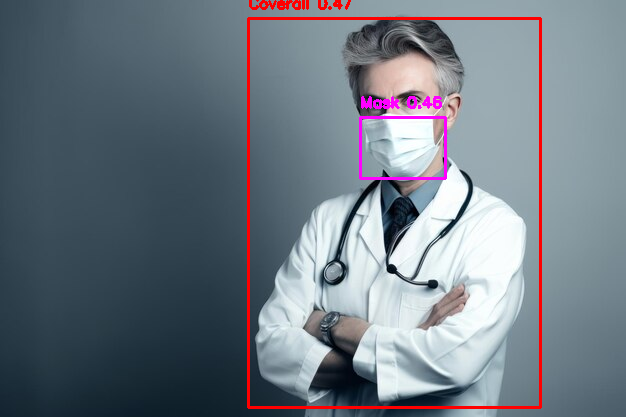


Found 2 objects:
  Coverall        confidence: 0.4734
  Mask            confidence: 0.4605


In [12]:
result, detections = upload_and_detect()